# Soccer Data Analysis

## Understanding Datasets and Data Cleaning 

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset 1 Euro Summary

In [2]:
df = pd.read_csv(r"euro_summary.csv")
df

,year,winner,final,result,matches,goals,red_cards,attendance,attendance_avg,goals_avg,red_cards_avg
0,1960,USSR,USSR - Yugoslavia,1 - 1,4,17,0,78958.0,19739.50,4.25,0.00
1,1964,Spain,Spain - USSR,2 - 2,4,13,0,156253.0,39063.25,3.25,0.00
2,1968,Italy,Italy - Yugoslavia,2 - 2,5,7,1,260936.0,52187.20,1.40,0.20
3,1972,West Germany,West Germany - USSR,3 - 3,4,10,0,106510.0,26627.50,2.50,0.00
4,1976,Czechoslovakia,Czechoslovakia - West Germany,2 - 2 (5 - 3),4,19,3,106087.0,26521.75,4.75,0.75
5,1980,West Germany,Belgium - West Germany,1 - 1,14,27,0,350655.0,25046.79,1.93,0.00
6,1984,France,France - Spain,2 - 2,15,41,3,599655.0,39977.00,2.73,0.20
7,1988,Netherlands,USSR - Netherlands,0 - 0,15,34,0,849844.0,56656.27,2.27,0.00
8,1992,Denmark,Denmark - Germany,2 - 2,15,32,0,429833.0,28655.53,2.13,0.00
9,1996,Germany,Czechia - Germany,1 - 1,31,64,7,1276171.0,41166.81,2.06,0.23


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            17 non-null     int64  
 1   winner          17 non-null     str    
 2   final           17 non-null     str    
 3   result          17 non-null     str    
 4   matches         17 non-null     int64  
 5   goals           17 non-null     int64  
 6   red_cards       17 non-null     int64  
 7   attendance      17 non-null     float64
 8   attendance_avg  17 non-null     float64
 9   goals_avg       17 non-null     float64
 10  red_cards_avg   17 non-null     float64
dtypes: float64(4), int64(4), str(3)
memory usage: 1.6 KB


In [4]:
df.isnull().sum()

year              0
winner            0
final             0
result            0
matches           0
goals             0
red_cards         0
attendance        0
attendance_avg    0
goals_avg         0
red_cards_avg     0
dtype: int64

### Country with most Euro Wins

In [5]:
winners_counts = df['winner'].value_counts()
winners_counts

winner
Spain             4
Italy             2
West Germany      2
France            2
USSR              1
Czechoslovakia    1
Netherlands       1
Denmark           1
Germany           1
Greece            1
Portugal          1
Name: count, dtype: int64

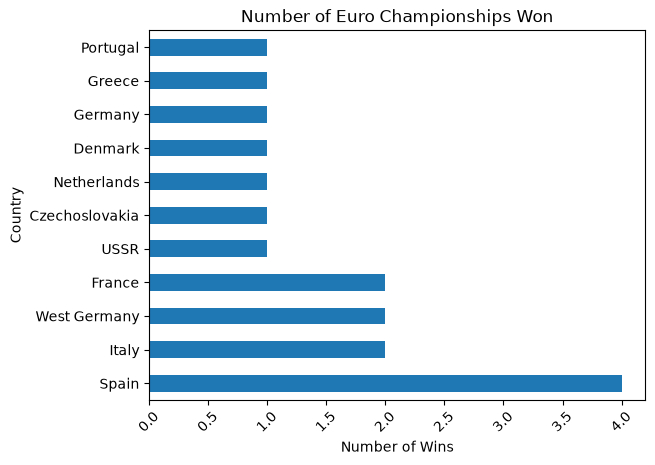

In [6]:
winners_counts.plot(kind = 'barh')
plt.title("Number of Euro Championships Won")
plt.ylabel("Country")
plt.xlabel("Number of Wins")
plt.xticks(rotation = 45)
plt.show()

### Tournament with Highest Number of Goals

In [7]:
df.loc[df['goals'].idxmax(),['year','goals']]

year     2020
goals     142
Name: 15, dtype: int64

### Tournamets with highest average attendance

In [8]:
df['attendance'] = df['attendance'].astype(int)

In [9]:
df.loc[df['attendance'].idxmax(),['year','goals','attendance']]

year             2024
goals             117
attendance    2681288
Name: 16, dtype: int64

### Number Of goals in Years

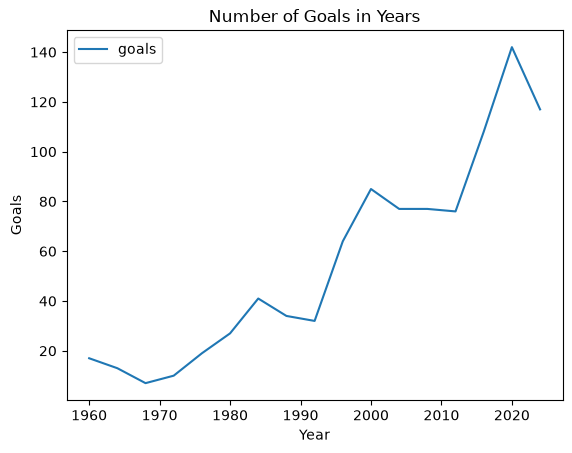

In [10]:
df.plot(x ='year',y = 'goals',kind = 'line')
plt.title("Number of Goals in Years")
plt.xlabel("Year")
plt.ylabel("Goals")
plt.show()

In [11]:
df.describe()

,year,matches,goals,red_cards,attendance,attendance_avg,goals_avg,red_cards_avg
count,17.00000,17.000000,17.000000,17.000000,1.700000e+01,17.000000,17.000000,17.000000
mean,1992.00000,22.823529,55.647059,2.823529,8.991269e+05,37306.062941,2.624118,0.135882
std,20.19901,17.161859,41.373212,2.743977,7.771803e+05,11337.587389,0.818711,0.182553
min,1960.00000,4.000000,7.000000,0.000000,7.895800e+04,19739.500000,1.400000,0.000000
25%,1976.00000,5.000000,19.000000,0.000000,2.609360e+05,26627.500000,2.130000,0.000000
50%,1992.00000,15.000000,41.000000,3.000000,8.498440e+05,37122.650000,2.480000,0.100000
75%,2008.00000,31.000000,77.000000,5.000000,1.150802e+06,46471.390000,2.740000,0.200000
max,2024.00000,51.000000,142.000000,8.000000,2.681288e+06,56656.270000,4.750000,0.750000


In [12]:
df.describe(include = 'str')

,winner,final,result
count,17,17,17
unique,11,17,7
top,Spain,USSR - Yugoslavia,2 - 2
freq,4,1,5


## Loading Dataset 2 Euro Coaches

In [13]:
df1 = pd.read_csv(r"euro_coaches.csv")
df1

,country_code,country,name,role,id_match,year
0,FRA,France,Albert Batteux,COACH,4024,1960
1,TCH,Czechoslovakia,Rudolf Vytlacil,COACH,4024,1960
2,URS,Soviet Union,Gavril Kachalin,COACH,4023,1960
3,TCH,Czechoslovakia,Rudolf Vytlacil,COACH,4023,1960
4,NaN,NaN,Konstantin Beskov,COACH,3996,1964
...,...,...,...,...,...,...
602,ESP,Spain,Luis de la Fuente,COACH,2036163,2024
603,SUI,Switzerland,Murat Yakin,COACH,2036162,2024
604,ITA,Italy,Marco Rossi,COACH,2036162,2024
605,SCO,Scotland,Steve Clarke,COACH,2036161,2024


In [14]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   country_code  602 non-null    str  
 1   country       602 non-null    str  
 2   name          607 non-null    str  
 3   role          607 non-null    str  
 4   id_match      607 non-null    int64
 5   year          607 non-null    int64
dtypes: int64(2), str(4)
memory usage: 28.6 KB


In [15]:
df1.describe()

,id_match,year
count,6.070000e+02,607.000000
mean,1.260448e+06,2009.528830
std,9.428403e+05,13.823334
min,6.000000e+00,1960.000000
25%,6.485900e+04,2000.000000
50%,2.017878e+06,2016.000000
75%,2.024466e+06,2020.000000
max,2.036211e+06,2024.000000


In [16]:
df1.describe(include = 'str')

,country_code,country,name,role
count,602,602,607,607
unique,33,33,147,2
top,GER,Germany,Joachim Löw,COACH
freq,70,70,20,606


In [17]:
for column in df1.columns:
    print(column)
    print(df1[column].unique(),'\n')

country_code
<StringArray>
['FRA', 'TCH', 'URS',   nan, 'ESP', 'DEN', 'HUN', 'SRB', 'ITA', 'ENG', 'BEL',
 'GER', 'CZE', 'NED', 'ROU', 'POR', 'UKR', 'SWE', 'CRO', 'RUS', 'TUR', 'SCO',
 'BUL', 'NOR', 'SVN', 'BRA', 'AUT', 'SUI', 'POL', 'WAL', 'SVK', 'NIR', 'FIN',
 'MKD']
Length: 34, dtype: str 

country
<StringArray>
[          'France',   'Czechoslovakia',     'Soviet Union',
                nan,            'Spain',          'Denmark',
          'Hungary',           'Serbia',            'Italy',
          'England',          'Belgium',          'Germany',
          'Czechia',      'Netherlands',          'Romania',
         'Portugal',          'Ukraine',           'Sweden',
          'Croatia',           'Russia',          'Türkiye',
         'Scotland',         'Bulgaria',           'Norway',
         'Slovenia',           'Brazil',          'Austria',
      'Switzerland',           'Poland',            'Wales',
         'Slovakia', 'Northern Ireland',          'Finland',
  'North Mace

In [18]:
df1.isnull().sum()

country_code    5
country         5
name            0
role            0
id_match        0
year            0
dtype: int64

In [19]:
df1[df1['country'].isnull()]

,country_code,country,name,role,id_match,year
4,NaN,NaN,Konstantin Beskov,COACH,3996,1964
8,NaN,NaN,Konstantin Beskov,COACH,3994,1964
61,NaN,NaN,Andy Roxburgh,COACH,5098,1992
69,NaN,NaN,Andy Roxburgh,COACH,5095,1992
74,NaN,NaN,Andy Roxburgh,COACH,5093,1992


In [20]:
df1[df1['name'].isin(['Konstantin Beskov','Andy Roxburgh'])]

,country_code,country,name,role,id_match,year
4,NaN,NaN,Konstantin Beskov,COACH,3996,1964
8,NaN,NaN,Konstantin Beskov,COACH,3994,1964
61,NaN,NaN,Andy Roxburgh,COACH,5098,1992
69,NaN,NaN,Andy Roxburgh,COACH,5095,1992
74,NaN,NaN,Andy Roxburgh,COACH,5093,1992


In [21]:
coach_fixes = {
    "Konstantin Beskov": {"country": "Soviet Union", "country_code": "URS"},
    "Andy Roxburgh":      {"country": "Scotland",      "country_code": "SCO"}
}

for name, vals in coach_fixes.items():
    df1.loc[df1['name'] == name, 'country'] = vals['country']
    df1.loc[df1['name'] == name, 'country_code'] = vals['country_code']
     

In [22]:
df1[df1['country'].isnull()]

,country_code,country,name,role,id_match,year


In [85]:
df1['role'].value_counts()

role
COACH              606
ASSISTANT_COACH      1
Name: count, dtype: int64

In [23]:
df1.duplicated().sum()

np.int64(0)

## Loading Dataset 3 Euro Lineups

In [24]:
df2 = pd.read_csv(r"euro_lineups.csv")
df2.head()

,country_code,name,name_shirt,jersey_namber,position_national,position_field,position_field_detailed,country_birth,birth_date,id_match,id_player,start,year,start_position_x,start_position_y,height,id_club,weight,id_national_team
0,SRB,Blagoje Vidinić,Vidinić,1.0,NaN,NaN,NaN,NaN,1934-06-11,4025,36774,field,1960,NaN,NaN,NaN,NaN,NaN,NaN
1,SRB,Vladimir Djurković,Durković,2.0,DEFENDER,DEFENDER,UNKNOWN,NaN,1937-11-06,4025,36735,field,1960,NaN,NaN,NaN,NaN,NaN,NaN
2,SRB,Fahrudin Jusufi,Jusufi,3.0,NaN,NaN,NaN,NaN,1939-12-08,4025,36723,field,1960,NaN,NaN,NaN,NaN,NaN,NaN
3,SRB,Ante Žanetić,Žanetić,4.0,NaN,NaN,NaN,NaN,1936-11-18,4025,36747,field,1960,NaN,NaN,NaN,NaN,NaN,NaN
4,SRB,Jovan Miladinović,Miladinović,5.0,NaN,NaN,NaN,NaN,1939-01-30,4025,36795,field,1960,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 16519 entries, 0 to 16518
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country_code             16388 non-null  str    
 1   name                     16519 non-null  str    
 2   name_shirt               15258 non-null  str    
 3   jersey_namber            16519 non-null  float64
 4   position_national        14633 non-null  str    
 5   position_field           14287 non-null  str    
 6   position_field_detailed  12242 non-null  str    
 7   country_birth            7067 non-null   str    
 8   birth_date               16516 non-null  str    
 9   id_match                 16519 non-null  int64  
 10  id_player                16519 non-null  int64  
 11  start                    16519 non-null  str    
 12  year                     16519 non-null  int64  
 13  start_position_x         8357 non-null   float64
 14  start_position_y         8357 non

In [26]:
df2.describe()

,jersey_namber,id_match,id_player,year,start_position_x,start_position_y,height,id_club,weight,id_national_team
count,16519.000000,1.651900e+04,1.651900e+04,16519.000000,8357.000000,8357.000000,8536.00000,9.198000e+03,8275.000000,8395.000000
mean,11.963254,1.103106e+06,8.367870e+07,2007.896120,298.326553,265.233696,182.59044,4.859695e+05,77.461390,13268.448481
std,6.836734,9.688616e+05,1.171017e+08,14.214923,306.072928,280.838975,10.08741,9.568827e+05,7.366362,31635.497288
min,1.000000,5.000000e+00,7.000000e+00,1960.000000,-1.000000,-1.000000,54.00000,1.652000e+03,58.000000,2.000000
25%,6.000000,6.485600e+04,2.490550e+04,2000.000000,-1.000000,-1.000000,178.00000,5.013600e+04,72.000000,47.000000
50%,12.000000,2.003327e+06,6.917300e+04,2012.000000,239.000000,249.000000,183.00000,5.280100e+04,77.000000,110.000000
75%,18.000000,2.024458e+06,2.500229e+08,2020.000000,502.000000,499.000000,188.00000,6.960000e+04,83.000000,135.000000
max,77.000000,2.036211e+06,2.501947e+08,2024.000000,927.000000,879.000000,202.00000,2.613172e+06,103.000000,700135.000000


In [27]:
missing=df2.isnull().sum()
missing

country_code                131
name                          0
name_shirt                 1261
jersey_namber                 0
position_national          1886
position_field             2232
position_field_detailed    4277
country_birth              9452
birth_date                    3
id_match                      0
id_player                     0
start                         0
year                          0
start_position_x           8162
start_position_y           8162
height                     7983
id_club                    7321
weight                     8244
id_national_team           8124
dtype: int64

In [28]:
missing = df2.isnull().sum()
null_percent = round(missing/len(df2)*100,2)
null_percent = null_percent.map(lambda x: f"{x:.2f}%")
missing_data = pd.DataFrame({'Total missing':missing,'null_percent':null_percent})
missing_data.sort_values(by='Total missing',ascending=False)

,Total missing,null_percent
country_birth,9452,57.22%
weight,8244,49.91%
start_position_y,8162,49.41%
start_position_x,8162,49.41%
id_national_team,8124,49.18%
height,7983,48.33%
id_club,7321,44.32%
position_field_detailed,4277,25.89%
position_field,2232,13.51%
position_national,1886,11.42%


In [29]:
df2.rename(columns = {'jersey_namber':'jersey_number'},inplace = True)

In [30]:
df2['start_position_y'].value_counts().sort_index()

start_position_y
-1.0      3389
 39.0        2
 42.0        1
 44.0        2
 46.0        1
          ... 
 862.0       2
 864.0       3
 868.0       1
 869.0       1
 879.0       1
Name: count, Length: 468, dtype: int64

In [31]:
df2['start_position_x'].value_counts().sort_index()


start_position_x
-1.0      3389
 72.0        1
 76.0        7
 84.0        6
 87.0        4
          ... 
 911.0       1
 912.0       4
 916.0       5
 923.0       7
 927.0       1
Name: count, Length: 440, dtype: int64

The `start_position_x` and `start_position_y` columns were removed because approximately 49% of their values  null
and 3389 values are `-1`, which appears to be a placeholder for missing or unavailable position data rather than a meaningful coordinate. Since nearly half of the observations lack valid positional information, imputing these values would introduce assumptions and could lead to misleading analysis.
Therefore, these columns were considered unreliable for the current analysis and were dropped.

In [32]:
df2 =  df2.drop(columns= ['country_birth','start_position_y','start_position_x'])

In [33]:
df2['start'].unique()

<StringArray>
['field', 'bench']
Length: 2, dtype: str

In [34]:
df2['country_code'] = df2['country_code'].fillna("Unknown")


In [35]:
df2 = df2.drop(columns= ['id_national_team','id_club'])

In [36]:
df2['name_shirt'] = df2['name_shirt'].fillna(df2['name'].str.split(" ").str[-1])

In [37]:
pd.set_option('display.max.rows',2061)

In [38]:
df2[df2['position_national'].notna() & df2['position_field'].notna() & (df2['position_national'] !=	df2['position_field'])]

,country_code,name,name_shirt,jersey_number,position_national,position_field,position_field_detailed,birth_date,id_match,id_player,start,year,height,weight
2017,SCO,Brian McClair,MC CLAIR,6.0,FORWARD,MIDFIELDER,UNKNOWN,1963-12-08,5098,77075,field,1992,NaN,NaN
2208,SCO,Brian McClair,MC CLAIR,6.0,FORWARD,MIDFIELDER,UNKNOWN,1963-12-08,5095,77075,field,1992,NaN,NaN
2346,SCO,Brian McClair,MC CLAIR,6.0,FORWARD,MIDFIELDER,UNKNOWN,1963-12-08,5093,77075,field,1992,NaN,NaN
4117,DEN,Jesper Grønkjær,Grønkjær,8.0,MIDFIELDER,FORWARD,UNKNOWN,1977-08-12,64867,23698,field,2000,187.0,82.0
4588,DEN,Jesper Grønkjær,Grønkjær,8.0,MIDFIELDER,FORWARD,UNKNOWN,1977-08-12,64866,23698,field,2000,187.0,82.0
4956,DEN,Jesper Grønkjær,Grønkjær,8.0,MIDFIELDER,FORWARD,UNKNOWN,1977-08-12,64863,23698,field,2000,187.0,82.0
5101,POR,Simão,Simão,11.0,FORWARD,MIDFIELDER,UNKNOWN,1979-10-31,79185,31345,bench,2004,174.0,64.0
5182,NED,Arjen Robben,Robben,19.0,FORWARD,MIDFIELDER,UNKNOWN,1984-01-23,79107,57134,field,2004,181.0,80.0
5192,POR,Simão,Simão,11.0,FORWARD,MIDFIELDER,UNKNOWN,1979-10-31,79107,31345,bench,2004,174.0,64.0
5225,DEN,Jesper Grønkjær,Grønkjær,8.0,MIDFIELDER,FORWARD,UNKNOWN,1977-08-12,79000,23698,field,2004,187.0,82.0


In [39]:
df2[df2['position_national'].notna() & df2['position_field'].notna() & (df2['position_national'] !=	df2['position_field'])]['position_national'].value_counts().sum()

np.int64(415)

In [40]:
df2['position_national'] = df2['position_national'].fillna(df2['position_field'])

In [41]:
df2['position_field'] = df2['position_field'].fillna(df2['position_national'])

In [42]:
df2['position_national'] = df2['position_national'].fillna("Unknown")

In [43]:
df2['position_field'] = df2['position_field'].fillna("Unknown")

In [44]:
missing = df2.isnull().sum()
missing

country_code                  0
name                          0
name_shirt                    0
jersey_number                 0
position_national             0
position_field                0
position_field_detailed    4277
birth_date                    3
id_match                      0
id_player                     0
start                         0
year                          0
height                     7983
weight                     8244
dtype: int64

In [45]:
df2['position_field_detailed'] = df2['position_field_detailed'].fillna("UNKNOWN")

In [46]:
df2['height'].describe()

count    8536.00000
mean      182.59044
std        10.08741
min        54.00000
25%       178.00000
50%       183.00000
75%       188.00000
max       202.00000
Name: height, dtype: float64

In [47]:
df2[df2['height'] < 140][['name', 'height']] 

,name,height
5325,Jean-Alain Boumsong,58.0
5611,Jean-Alain Boumsong,58.0
5926,Jean-Alain Boumsong,58.0
6311,Jean-Alain Boumsong,58.0
6847,Nikos Liberopoulos,57.0
6884,Jean-Alain Boumsong,58.0
6991,Erwin Hoffer,54.0
7031,Marcin Wasilewski,57.0
7040,Martin Fenin,55.0
7171,Nikos Liberopoulos,57.0


In [48]:
df2.loc[df2['height']<140,'height'] = np.nan

In [49]:
df2['height'].isnull().sum()

np.int64(8012)

Approximately 50% of the height and weight values are missing.
Since imputing such a large proportion of the data with the mean or median could artificially alter the height and weight distribution and potentially bias the analysis, no imputation was performed.
The missing values were retained as null, and the available non-null height values were used for distribution analysis, including the box plot.

In [50]:
df2['weight'].describe()

count    8275.000000
mean       77.461390
std         7.366362
min        58.000000
25%        72.000000
50%        77.000000
75%        83.000000
max       103.000000
Name: weight, dtype: float64

In [51]:
df2.duplicated().sum()

np.int64(0)

### No Duplicate Values

In [52]:
df2.isnull().sum()

country_code                  0
name                          0
name_shirt                    0
jersey_number                 0
position_national             0
position_field                0
position_field_detailed       0
birth_date                    3
id_match                      0
id_player                     0
start                         0
year                          0
height                     8012
weight                     8244
dtype: int64

In [53]:
df2['birth_date'] = pd.to_datetime(df2['birth_date'],format = "%Y-%m-%d")

In [54]:
df2['birth_date'] = df2['birth_date'].fillna(df2['birth_date'].mode()[0])

In [55]:
df2['jersey_number'] = df2['jersey_number'].astype(int) 

In [56]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 16519 entries, 0 to 16518
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   country_code             16519 non-null  str           
 1   name                     16519 non-null  str           
 2   name_shirt               16519 non-null  str           
 3   jersey_number            16519 non-null  int64         
 4   position_national        16519 non-null  str           
 5   position_field           16519 non-null  str           
 6   position_field_detailed  16519 non-null  str           
 7   birth_date               16519 non-null  datetime64[us]
 8   id_match                 16519 non-null  int64         
 9   id_player                16519 non-null  int64         
 10  start                    16519 non-null  str           
 11  year                     16519 non-null  int64         
 12  height                   8507 non-null   fl

# Exploratory Data Analysis

In [57]:
pd.set_option('display.max_columns', 33)

In [58]:
df2['age_at_tournament'] = df2.apply(lambda row: row['year']-row['birth_date'].year,axis=1)
df2.head(25)

,country_code,name,name_shirt,jersey_number,position_national,position_field,position_field_detailed,birth_date,id_match,id_player,start,year,height,weight,age_at_tournament
0,SRB,Blagoje Vidinić,Vidinić,1,Unknown,Unknown,UNKNOWN,1934-06-11,4025,36774,field,1960,NaN,NaN,26
1,SRB,Vladimir Djurković,Durković,2,DEFENDER,DEFENDER,UNKNOWN,1937-11-06,4025,36735,field,1960,NaN,NaN,23
2,SRB,Fahrudin Jusufi,Jusufi,3,Unknown,Unknown,UNKNOWN,1939-12-08,4025,36723,field,1960,NaN,NaN,21
3,SRB,Ante Žanetić,Žanetić,4,Unknown,Unknown,UNKNOWN,1936-11-18,4025,36747,field,1960,NaN,NaN,24
4,SRB,Jovan Miladinović,Miladinović,5,Unknown,Unknown,UNKNOWN,1939-01-30,4025,36795,field,1960,NaN,NaN,21
5,SRB,Željko Perušić,Perušić,6,Unknown,Unknown,UNKNOWN,1936-03-23,4025,36727,field,1960,NaN,NaN,24
6,SRB,Željko Matuš,Matuš,7,Unknown,Unknown,UNKNOWN,1935-08-09,4025,92424,field,1960,NaN,NaN,25
7,SRB,Dražan Jerković,Jerković,8,Unknown,Unknown,UNKNOWN,1936-08-06,4025,36775,field,1960,NaN,NaN,24
8,SRB,Milan Galić,Galić,9,FORWARD,FORWARD,UNKNOWN,1938-03-08,4025,36722,field,1960,NaN,NaN,22
9,SRB,Dragoslav Šekularac,Šekularac,10,FORWARD,FORWARD,UNKNOWN,1937-11-30,4025,36732,field,1960,NaN,NaN,23


### Average Height & Age: Winning Squad vs Rest of Field

                      height  age_at_tournament
is_winning_squad                               
False             183.165056          27.372494
True              181.225505          27.415003


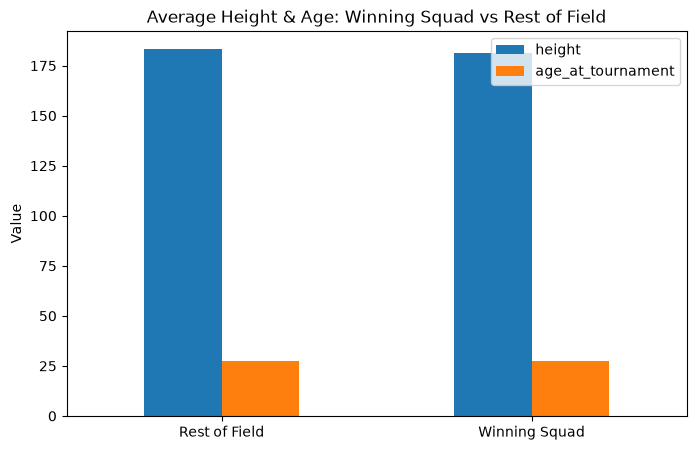

In [93]:
# euro_summary['winner'] is a country name; euro_lineups only has country_code, so build a code lookup
# from euro_coaches (which has both code and name) as a bridge table
code_to_name = df1.drop_duplicates('country_code').set_index('country_code')['country'].to_dict()
df2['country_name'] = df2['country_code'].map(code_to_name)

# Flag winner rows using the country_name_map applied to df['winner'] for consistency
winner_name_fix = {'USSR': 'Soviet Union', 'West Germany': 'Germany'}
df['winner_std'] = df['winner'].replace(winner_name_fix)
winners_by_year = df.set_index('year')['winner_std'].to_dict()
df2['tournament_winner'] = df2['year'].map(winners_by_year)
df2['is_winning_squad'] = df2['country_name'] == df2['tournament_winner']
# Compare average height and age
comparison = df2.groupby('is_winning_squad')[['height', 'age_at_tournament']].mean()
print(comparison)
comparison.index = ['Rest of Field', 'Winning Squad']
comparison.plot(kind='bar', figsize=(8,5), rot=0)
plt.title("Average Height & Age: Winning Squad vs Rest of Field")
plt.ylabel("Value")
plt.show()

### t-test in Height and Age

In [62]:
from scipy import stats

# ---- Height t-test ----
winning_height = df2[df2['is_winning_squad']]['height'].dropna()
rest_height    = df2[~df2['is_winning_squad']]['height'].dropna()

t_h, p_h = stats.ttest_ind(winning_height, rest_height, equal_var=False)  
print("HEIGHT")
print(f"Winning squad mean: {winning_height.mean():.2f} cm  (n={len(winning_height)})")
print(f"Rest of field mean: {rest_height.mean():.2f} cm  (n={len(rest_height)})")
print(f"t-statistic: {t_h:.3f}, p-value: {p_h:.4f}")
print("Statistically significant (p<0.05)" if p_h < 0.05 else "Not statistically significant (p>=0.05)")
print()

# ---- Age t-test ----
winning_age = df2[df2['is_winning_squad']]['age_at_tournament'].dropna()
rest_age    = df2[~df2['is_winning_squad']]['age_at_tournament'].dropna()

t_a, p_a = stats.ttest_ind(winning_age, rest_age, equal_var=False)
print("AGE")
print(f"Winning squad mean: {winning_age.mean():.2f} years  (n={len(winning_age)})")
print(f"Rest of field mean: {rest_age.mean():.2f} years  (n={len(rest_age)})")
print(f"t-statistic: {t_a:.3f}, p-value: {p_a:.4f}")
print("Statistically significant (p<0.05)" if p_a < 0.05 else "Not statistically significant (p>=0.05)")


HEIGHT
Winning squad mean: 181.11 cm  (n=639)
Rest of field mean: 183.17 cm  (n=7868)
t-statistic: -6.327, p-value: 0.0000
Statistically significant (p<0.05)

AGE
Winning squad mean: 27.52 years  (n=1351)
Rest of field mean: 27.36 years  (n=15168)
t-statistic: 1.468, p-value: 0.1423
Not statistically significant (p>=0.05)


**Winning-squad players were significantly shorter on average (p < 0.001), while there was no significant difference in age (p = 0.1423).**

### Position distribution of players Field vs Bench

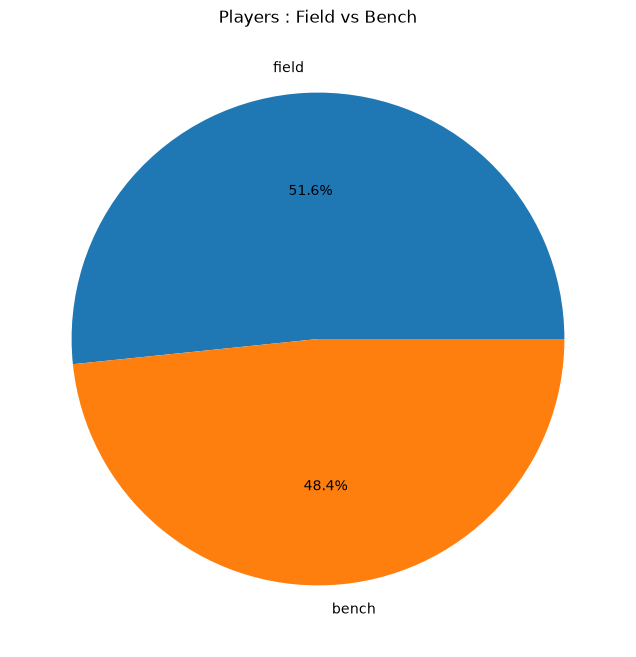

In [63]:
plt.figure(figsize = (8,8))
df2['start'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%')
plt.title("Players : Field vs Bench")
plt.ylabel("")
plt.show()

### Total Attendence By Tournament 

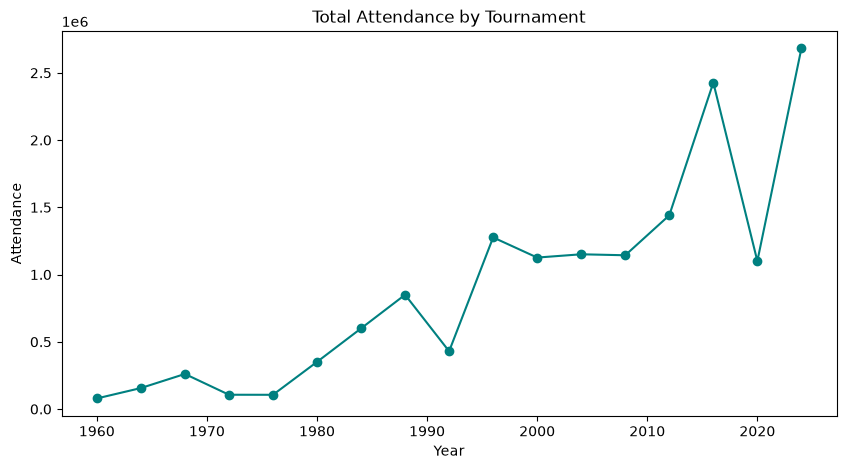

In [64]:
plt.figure(figsize=(10,5))
plt.plot(df['year'], df['attendance'], marker='o', color='teal')
plt.title("Total Attendance by Tournament")
plt.xlabel("Year")
plt.ylabel("Attendance")
plt.show()

### Goals average per Mtach

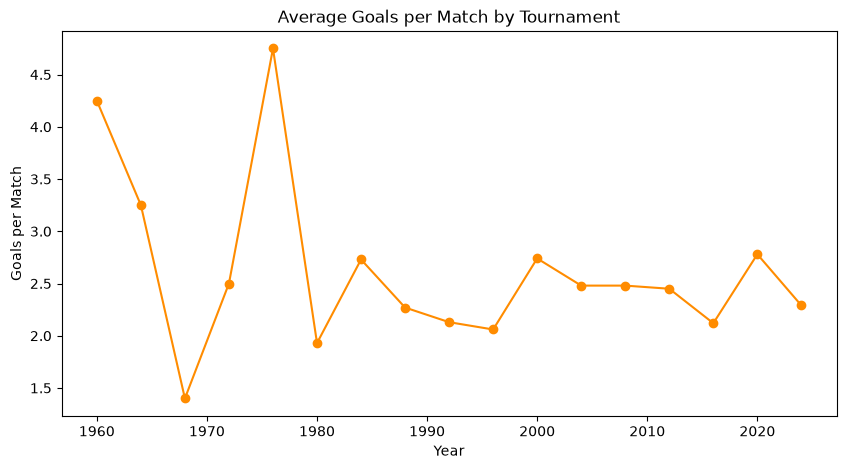

In [65]:
plt.figure(figsize=(10,5))
plt.plot(df['year'], df['goals_avg'], marker='o', color='darkorange')
plt.title("Average Goals per Match by Tournament")
plt.xlabel("Year")
plt.ylabel("Goals per Match")
plt.show()

### Red Card Issued

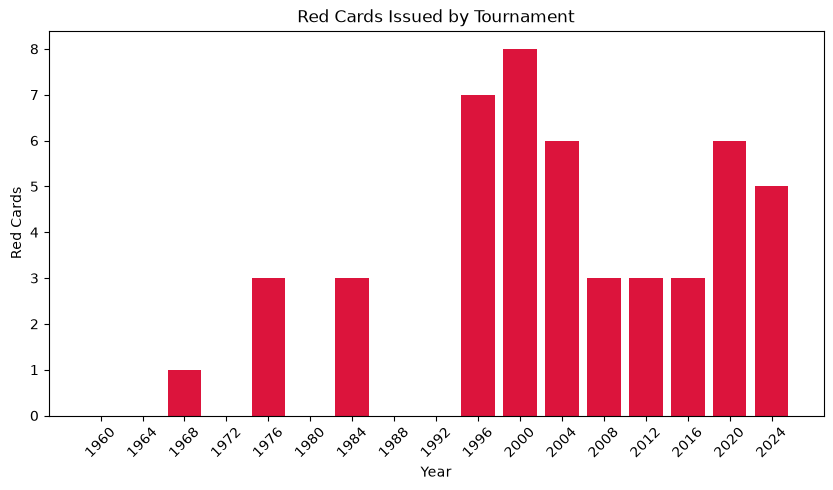

In [66]:
plt.figure(figsize=(10,5))
plt.bar(df['year'].astype(str), df['red_cards'], color='crimson')
plt.title("Red Cards Issued by Tournament")
plt.xlabel("Year")
plt.ylabel("Red Cards")
plt.xticks(rotation=45)
plt.show()

### Wins by decade

In [67]:
df['decade'] = (df['year'] // 10) * 10
decade_wins = df.groupby('decade')['winner'].apply(lambda x: x.value_counts().idxmax())
print(decade_wins)

decade
1960            USSR
1970    West Germany
1980    West Germany
1990         Denmark
2000          France
2010           Spain
2020           Italy
Name: winner, dtype: str


### Top coaches by number of matches coached

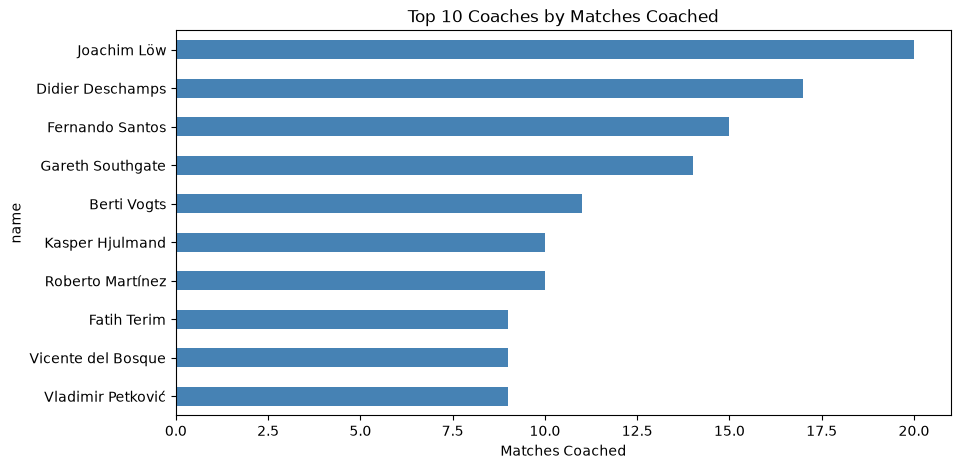

In [68]:
top_coaches = df1['name'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_coaches.plot(kind='barh', color='steelblue')
plt.title("Top 10 Coaches by Matches Coached")
plt.xlabel("Matches Coached")
plt.gca().invert_yaxis()
plt.show()

### Coaching turnover by country (unique coaches per country)

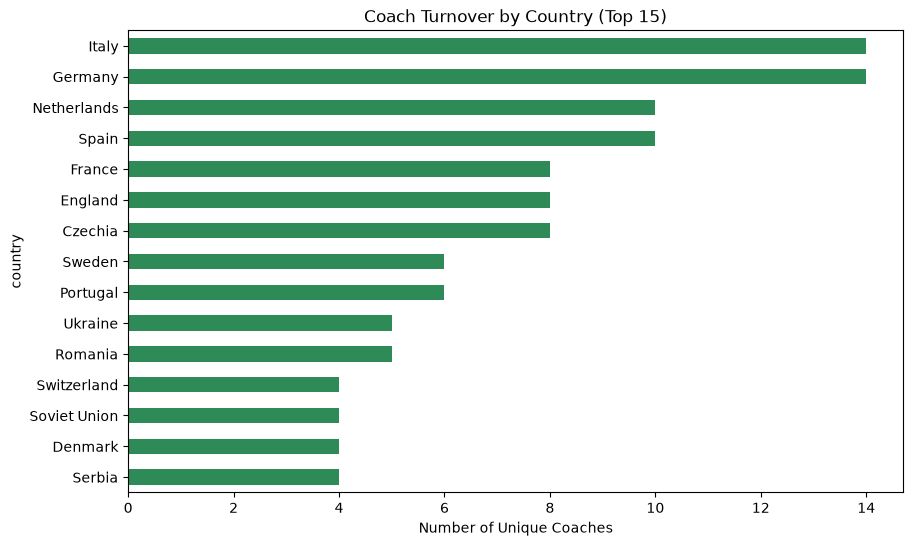

In [69]:
turnover = df1.groupby('country')['name'].nunique().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
turnover.plot(kind='barh', color='seagreen')
plt.title("Coach Turnover by Country (Top 15)")
plt.xlabel("Number of Unique Coaches")
plt.gca().invert_yaxis()
plt.show()

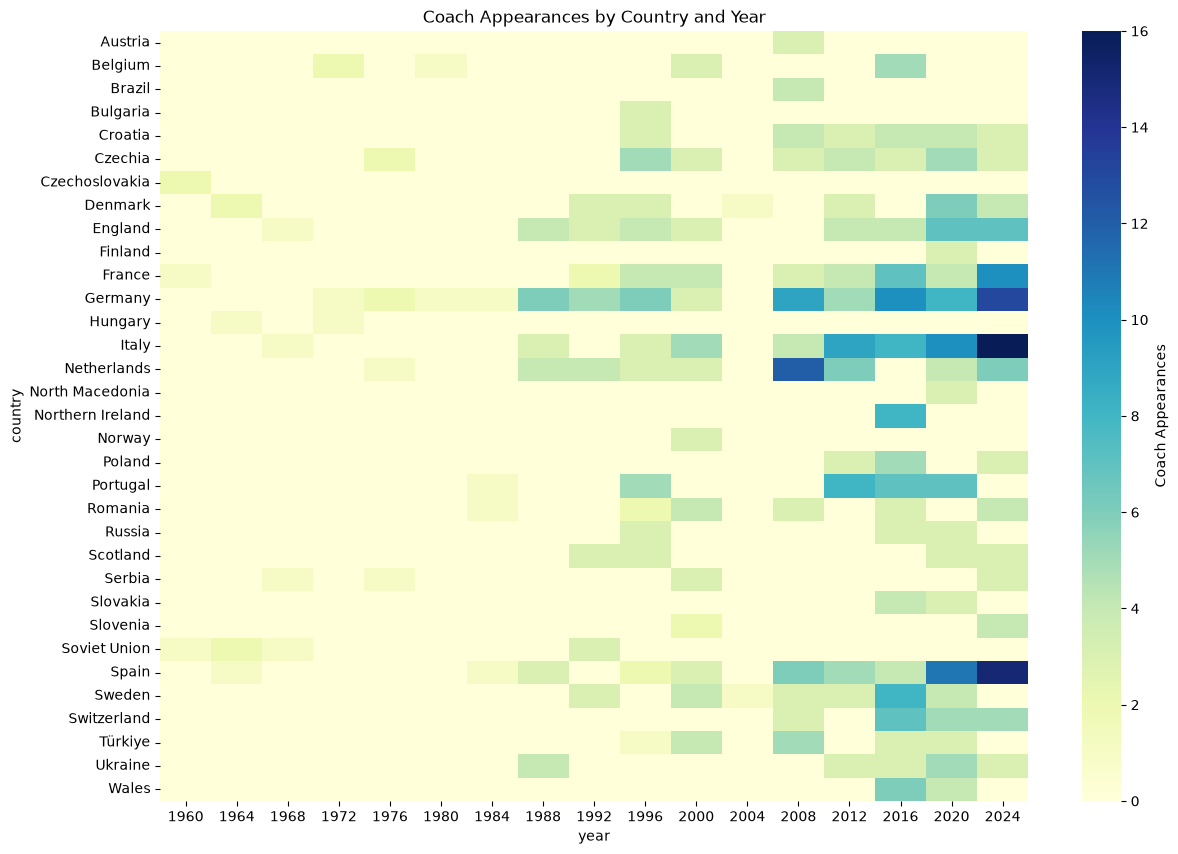

In [70]:
# Coaches per country per year — timeline (crosstab heatmap)
timeline = pd.crosstab(df1['country'], df1['year'])
plt.figure(figsize=(14,10))
sns.heatmap(timeline, cmap='YlGnBu', cbar_kws={'label':'Coach Appearances'})
plt.title("Coach Appearances by Country and Year")
plt.show()

### Position distribution overall

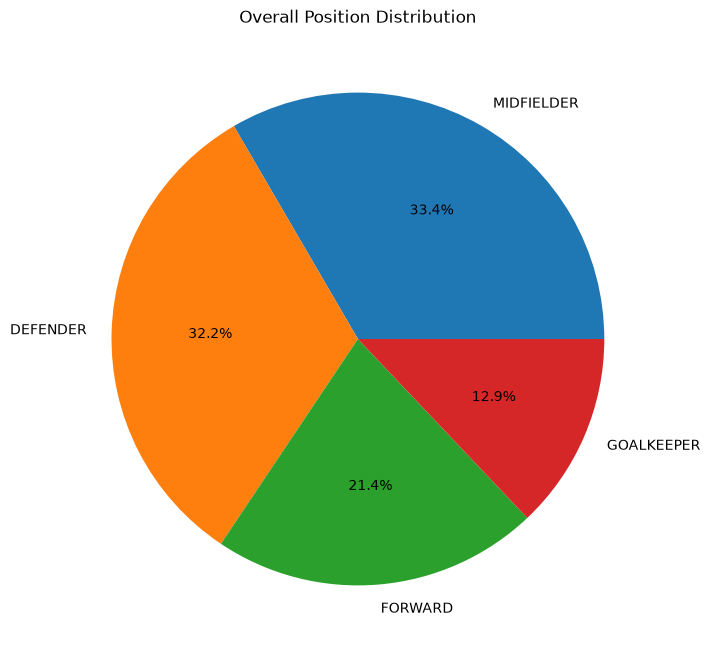

In [71]:
position_counts = df2[df2['position_field']!= 'Unknown']['position_field'].value_counts()
plt.figure(figsize = (8,8))
position_counts.plot(kind = 'pie', autopct = '%1.1f%%')
plt.title("Overall Position Distribution")
plt.ylabel("")
plt.show()

In [72]:
# Create a copy of the coaches dataset
coaches = df1[['year', 'country', 'name']].copy()

# Make country names consistent with the winner column
country_mapping = {
    'USSR': 'Soviet Union',
    'West Germany': 'Germany',
    'Czechoslovakia': 'Czechoslovakia'
}

coaches['country_merge'] = coaches['country'].replace(country_mapping)

# Merge using year + standardized country
winning_coaches = df.merge(
    coaches,
    left_on=['year', 'winner'],
    right_on=['year', 'country_merge'],
    how='left'
)

# Keep required columns
winning_coaches = winning_coaches[
    ['year', 'winner', 'name']
].drop_duplicates()

# Rename coach column
winning_coaches = winning_coaches.rename(
    columns={'name': 'winning_coach'}
)

winning_coaches

,year,winner,winning_coach
0,1960,USSR,NaN
1,1964,Spain,José Villalonga
2,1968,Italy,Ferruccio Valcareggi
3,1972,West Germany,NaN
4,1976,Czechoslovakia,NaN
5,1980,West Germany,NaN
6,1984,France,NaN
7,1988,Netherlands,Rinus Michels
11,1992,Denmark,Richard Møller-nielsen
14,1996,Germany,Berti Vogts


### Coaches of winning team

In [91]:
winning_coaches = winning_coaches.drop_duplicates(subset=['year', 'winner']).reset_index(drop=True)

coach_mapping = {1976: 'Václav Ježek',1984: 'Michel Hidalgo'}

winning_coaches['winning_coach'] = winning_coaches.apply(lambda row: coach_mapping.get(row['year'], row['winning_coach']),axis=1)
winning_coaches

,year,winner,winning_coach
0,1960,USSR,Gavril Kachalin
1,1964,Spain,José Villalonga
2,1968,Italy,Ferruccio Valcareggi
3,1972,West Germany,Helmut Schön
4,1976,Czechoslovakia,Václav Ježek
5,1980,West Germany,Jupp Derwall
6,1984,France,Michel Hidalgo
7,1988,Netherlands,Rinus Michels
8,1992,Denmark,Richard Møller-nielsen
9,1996,Germany,Berti Vogts


### Height by position (box plot)

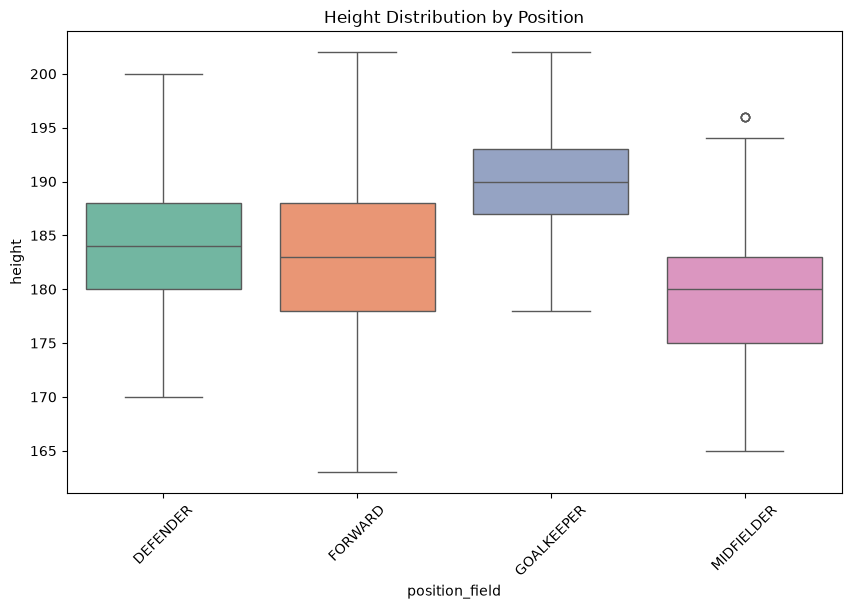

In [89]:
known_pos = df2[df2['position_field'] != 'Unknown']
plt.figure(figsize=(10,6))
sns.boxplot(data=known_pos, x='position_field', y='height', hue='position_field', palette='Set2', legend=False)
plt.title('Height Distribution by Position')
plt.xticks(rotation=45)
plt.show()

### Weight by position (box plot)

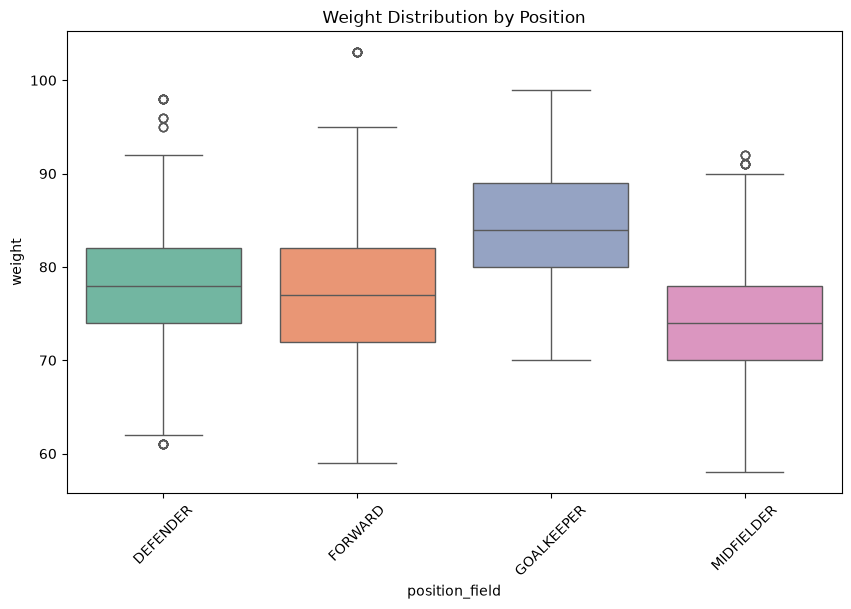

In [92]:
known_pos = df2[df2['position_field'] != 'Unknown']
plt.figure(figsize=(10,6))
sns.boxplot(data=known_pos, x='position_field', y='weight', hue='position_field', palette='Set2', legend=False)
plt.title('Weight Distribution by Position')
plt.xticks(rotation=45)
plt.show()

### Age distribution at tournament

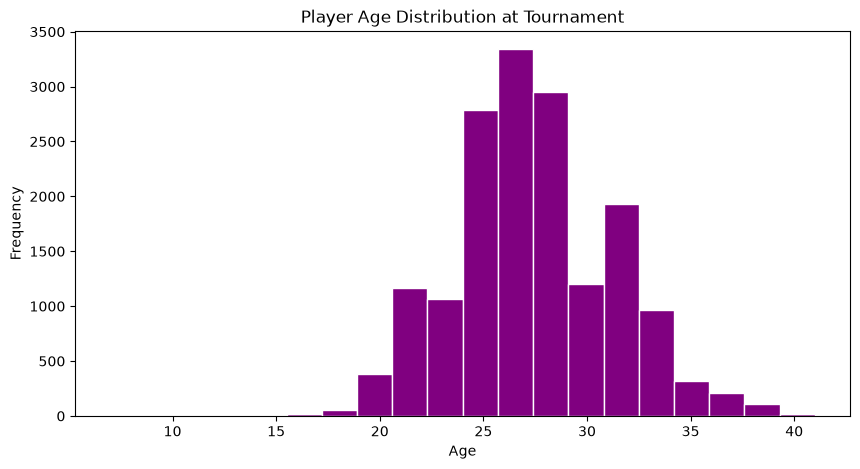

In [88]:
plt.figure(figsize=(10,5))
df2['age_at_tournament'].dropna().plot(kind='hist', bins=20, color='purple', edgecolor='white')
plt.title("Player Age Distribution at Tournament")
plt.xlabel("Age")
plt.show()

### Most-capped players (appearances across matches)

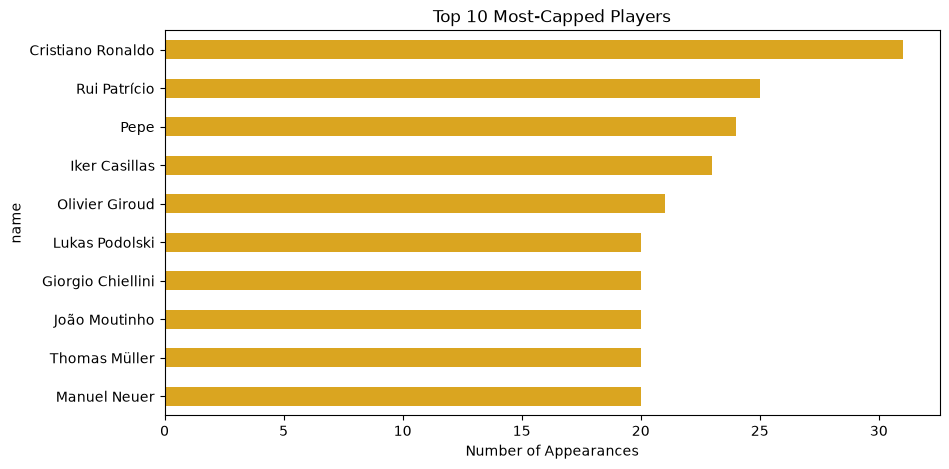

In [78]:
most_capped = df2['name'].value_counts().head(10)
plt.figure(figsize=(10,5))
most_capped.plot(kind='barh', color='goldenrod')
plt.title("Top 10 Most-Capped Players")
plt.xlabel("Number of Appearances")
plt.gca().invert_yaxis()
plt.show()

### Using Correlation Finding Average Attendance and Goals per Match Relation

Attendance vs total goals: r=0.836, p=0.000
Attendance/match vs goals/match: r=-0.523, p=0.031


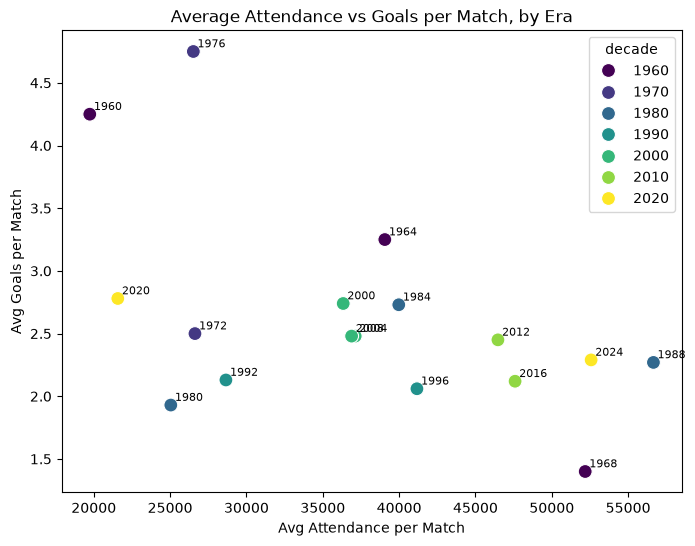

In [79]:
from scipy import stats

# Raw correlation
corr, p_value = stats.pearsonr(df['attendance'], df['goals'])
print(f"Attendance vs total goals: r={corr:.3f}, p={p_value:.3f}")

# Better-controlled version: attendance_avg vs goals_avg (per-match, removes tournament-size effect)
corr_avg, p_avg = stats.pearsonr(df['attendance_avg'], df['goals_avg'])
print(f"Attendance/match vs goals/match: r={corr_avg:.3f}, p={p_avg:.3f}")

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='attendance_avg', y='goals_avg', hue='decade', palette='viridis', s=100)
for _, row in df.iterrows():
    plt.annotate(str(row['year']), (row['attendance_avg'], row['goals_avg']), fontsize=8, xytext=(3,3), textcoords='offset points')
plt.title("Average Attendance vs Goals per Match, by Era")
plt.xlabel("Avg Attendance per Match")
plt.ylabel("Avg Goals per Match")
plt.show()

# Conclusion and Inferences

**Tournament Success:**
- Spain is the most successful team in Euro history with 4 titles.
- West Germany, Italy, and France have 2 titles each. The other winning teams have won once.

**Squad Composition:** 
- Winning squads had an average height of **181.11 cm** and age of **27.52 years**.
-  The t-test showed a significant difference in height, but no significant difference in age.

**Attendance vs. Goals:**
- Attendance and total goals had a positive correlation.
- But after calculating goals per match, the correlation became negative (**r = -0.523, p = 0.031**).
- This means tournaments with higher attendance tended to have slightly fewer goals per match.

**Coaching Stability:**
- Some teams kept the same coach for several tournaments, while others changed coaches more often.
- This could be studied further to see if coaching stability affects success.

**Data Quality:** 
- About half of the height and weight data had missing values. The missing values were retained as null, and the available non-null height and weight values were used for distribution analysis, including the box plot
- Some other columns had too many missing values and were dropped. This may affect some of the analysis.

**Overall Takeaway:** 
-Winning a tournament cannot be explained by age or height alone. 
Also, normalizing the data, such as using goals per match instead of total goals, gives more meaningful results.
